# Notebook from Hugging Face
# Unit 4: Code your first Deep Reinforcement Learning Algorithm with PyTorch: Reinforce. And test its robustness 💪

<img src="https://huggingface.co/datasets/huggingface-deep-rl-course/course-images/resolve/main/en/unit6/thumbnail.png" alt="thumbnail"/>


In this notebook, you'll code your first Deep Reinforcement Learning algorithm from scratch: Reinforce (also called Monte Carlo Policy Gradient).

Reinforce is a *Policy-based method*: a Deep Reinforcement Learning algorithm that tries **to optimize the policy directly without using an action-value function**.

More precisely, Reinforce is a *Policy-gradient method*, a subclass of *Policy-based methods* that aims **to optimize the policy directly by estimating the weights of the optimal policy using gradient ascent**.

To test its robustness, we're going to train it in 2 different simple environments:
- Cartpole-v1
- PixelcopterEnv

⬇️ Here is an example of what **you will achieve at the end of this notebook.** ⬇️

  <img src="https://huggingface.co/datasets/huggingface-deep-rl-course/course-images/resolve/main/en/unit6/envs.gif" alt="Environments"/>


### 🎮 Environments:

- [CartPole-v1](https://www.gymlibrary.dev/environments/classic_control/cart_pole/)
- [PixelCopter](https://pygame-learning-environment.readthedocs.io/en/latest/user/games/pixelcopter.html)

### 📚 RL-Library:

- Python
- PyTorch


We're constantly trying to improve our tutorials, so **if you find some issues in this notebook**, please [open an issue on the GitHub Repo](https://github.com/huggingface/deep-rl-class/issues).

## Objectives of this notebook 🏆
At the end of the notebook, you will:
- Be able to **code from scratch a Reinforce algorithm using PyTorch.**
- Be able to **test the robustness of your agent using simple environments.**
- Be able to **push your trained agent to the Hub** with a nice video replay and an evaluation score 🔥.

## This notebook is from the Deep Reinforcement Learning Course
<img src="https://huggingface.co/datasets/huggingface-deep-rl-course/course-images/resolve/main/en/notebooks/deep-rl-course-illustration.jpg" alt="Deep RL Course illustration"/>

In this free course, you will:

- 📖 Study Deep Reinforcement Learning in **theory and practice**.
- 🧑‍💻 Learn to **use famous Deep RL libraries** such as Stable Baselines3, RL Baselines3 Zoo, CleanRL and Sample Factory 2.0.
- 🤖 Train **agents in unique environments**

And more check 📚 the syllabus 👉 https://simoninithomas.github.io/deep-rl-course

The best way to keep in touch is to join our discord server to exchange with the community and with us 👉🏻 https://discord.gg/ydHrjt3WP5

## Prerequisites 🏗️
Before diving into the notebook, you need to:

🔲 📚 Course l03_policy_gradient_2_actor_critic_2_ppo.pdf
or
🔲 📚 [Study Policy Gradients by reading Unit 4](https://huggingface.co/deep-rl-course/unit4/introduction)

# Let's code Reinforce algorithm from scratch 🔥


To validate this hands-on for the certification process, you need to push your trained models to the Hub.

- Get a result of >= 350 for `Cartpole-v1`.
- Get a result of >= 5 for `PixelCopter`.

In [1]:
# Virtual display
from pyvirtualdisplay import Display

virtual_display = Display(visible=0, size=(1400, 900))
virtual_display.start()

# Import all dependencies

In [2]:
import numpy as np

from collections import deque

import matplotlib.pyplot as plt
%matplotlib inline

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

# Gym
import gymnasium as gym

# Create images
import imageio

## Check if we have a GPU

- Let's check if we have a GPU
- If it's the case you should see `device:cuda0`

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
print(device)

cuda:0


We're now ready to implement our Reinforce algorithm 🔥

# First agent: Playing CartPole-v1 🤖

## Create the CartPole environment and understand how it works
### [The environment 🎮](https://gymnasium.farama.org/environments/classic_control/cart_pole/)



### Why do we use a simple environment like CartPole-v1?
As explained in [Reinforcement Learning Tips and Tricks](https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html), when you implement your agent from scratch you need **to be sure that it works correctly and find bugs with easy environments before going deeper**. Since finding bugs will be much easier in simple environments.


> Try to have some “sign of life” on toy problems


> Validate the implementation by making it run on harder and harder envs (you can compare results against the RL zoo). You usually need to run hyperparameter optimization for that step.
___
### The CartPole-v1 environment

> A pole is attached by an un-actuated joint to a cart, which moves along a frictionless track. The pendulum is placed upright on the cart and the goal is to balance the pole by applying forces in the left and right direction on the cart.



So, we start with CartPole-v1. The goal is to push the cart left or right **so that the pole stays in the equilibrium.**

The episode ends if:
- The pole Angle is greater than ±12°
- Cart Position is greater than ±2.4
- Episode length is greater than 500

We get a reward 💰 of +1 every timestep the Pole stays in the equilibrium.

Getting a cumulated reward of 500 over one episode is then the maximum possible.

In [5]:
env_id = "CartPole-v1"
# Create the env
env = gym.make(env_id, render_mode="rgb_array")

# Create the evaluation env
eval_env = gym.make(env_id, render_mode="rgb_array")

# Get the state space and action space
s_size = env.observation_space.shape[0]
a_size = env.action_space.n

In [6]:
print("_____OBSERVATION SPACE_____ \n")
print("The State Space is: ", s_size)
print("Sample observation", env.observation_space.sample()) # Get a random observation

_____OBSERVATION SPACE_____ 

The State Space is:  4
Sample observation [-1.821164    0.6043029  -0.17819722  1.0772654 ]


In [7]:
print("\n _____ACTION SPACE_____ \n")
print("The Action Space is: ", a_size)
print("Action Space Sample", env.action_space.sample()) # Take a random action


 _____ACTION SPACE_____ 

The Action Space is:  2
Action Space Sample 1


## Let's build the Reinforce Architecture
This implementation is based on two implementations:
- [PyTorch official Reinforcement Learning example](https://github.com/pytorch/examples/blob/main/reinforcement_learning/reinforce.py)
- [Udacity Reinforce](https://github.com/udacity/deep-reinforcement-learning/blob/master/reinforce/REINFORCE.ipynb)
- [Improvement of the integration by Chris1nexus](https://github.com/huggingface/deep-rl-class/pull/95)

<img src="https://huggingface.co/datasets/huggingface-deep-rl-course/course-images/resolve/main/en/unit6/reinforce.png" alt="Reinforce"/>

So we want:
- Two fully connected layers (fc1 and fc2).
- Using ReLU as activation function of fc1
- Using Softmax to output a probability distribution over actions

In [8]:
class Policy(nn.Module):
    def __init__(self, s_size, a_size, h_size):
        super(Policy, self).__init__()
        self.s_size = s_size
        self.a_size = a_size
        self.h_size = h_size
        # Create two fully connected layers
        print("TODO : create the 2 fully connected layers !")


    def forward(self, x):
        # Define the forward pass
        # state goes to fc1 then we apply ReLU activation function
        print("TODO : Compute the output by fc1 and relu activation function")
        # fc1 outputs goes to fc2
        print("TODO : Compute the output by fc2 of the previous output")
        # We output the softmax
        print("TODO : apply softmax to output")
        

    def act(self, state):
        """
        Given a state, take action
        """
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        m = Categorical(probs)
        action = np.argmax(m)
        return action.item(), m.log_prob(action)

### Solution

In [9]:
class Policy(nn.Module):
    def __init__(self, s_size, a_size, h_size):
        super(Policy, self).__init__()
        self.s_size = s_size
        self.a_size = a_size
        self.h_size = h_size
        self.fc1 = nn.Linear(self.s_size, self.h_size)
        self.fc2 = nn.Linear(self.h_size, self.a_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.softmax(x, dim=1)

    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        m = Categorical(probs)
        action = np.argmax(m)
        return action.item(), m.log_prob(action)

I make a mistake, can you guess where?

- To find out let's make a forward pass:

In [10]:
debug_policy = Policy(s_size, a_size, 64).to(device)
s0, info = env.reset()
debug_policy.act(s0)

ValueError: The value argument to log_prob must be a Tensor

- Here we see that the error says `ValueError: The value argument to log_prob must be a Tensor`

- It means that `action` in `m.log_prob(action)` must be a Tensor **but it's not.**

- Do you know why? Check the act function and try to see why it does not work.

Advice 💡: Something is wrong in this implementation. Remember that we act function **we want to sample an action from the probability distribution over actions**.


### (Real) Solution

In [11]:
class Policy(nn.Module):
    def __init__(self, s_size, a_size, h_size):
        super(Policy, self).__init__()
        self.s_size = s_size
        self.a_size = a_size
        self.h_size = h_size
        self.fc1 = nn.Linear(self.s_size, self.h_size)
        self.fc2 = nn.Linear(self.h_size, self.a_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.softmax(x, dim=1)

    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        m = Categorical(probs)
        action = m.sample()
        return action.item(), m.log_prob(action)

In [12]:
debug_policy = Policy(s_size, a_size, 64).to(device)
s0,info = env.reset()
debug_policy.act(s0)

(0, tensor([-0.6618], grad_fn=<SqueezeBackward1>))

By using CartPole, it was easier to debug since **we know that the bug comes from our integration and not from our simple environment**.

- Since **we want to sample an action from the probability distribution over actions**, we can't use `action = np.argmax(m)` since it will always output the action that have the highest probability.

- We need to replace with `action = m.sample()` that will sample an action from the probability distribution P(.|s)

### Let's build the Reinforce Training Algorithm
This is the Reinforce algorithm pseudocode:

<img src="https://huggingface.co/datasets/huggingface-deep-rl-course/course-images/resolve/main/en/unit6/pg_pseudocode.png" alt="Policy gradient pseudocode"/>
  

- When we calculate the return Gt (line 6) we see that we calculate the sum of discounted rewards **starting at timestep t**.

- Why? Because our policy should only **reinforce actions on the basis of the consequences**: so rewards obtained before taking an action are useless (since they were not because of the action), **only the ones that come after the action matters**.

- Before coding this you should read this section [don't let the past distract you](https://spinningup.openai.com/en/latest/spinningup/rl_intro3.html#don-t-let-the-past-distract-you) that explains why we use reward-to-go policy gradient.

We use an interesting technique coded by [Chris1nexus](https://github.com/Chris1nexus) to **compute the return at each timestep efficiently**. The comments explained the procedure. Don't hesitate also [to check the PR explanation](https://github.com/huggingface/deep-rl-class/pull/95)
But overall the idea is to **compute the return at each timestep efficiently**.

The second question you may ask is **why do we minimize the loss**? You talked about Gradient Ascent not Gradient Descent?

- We want to maximize our utility function $J(\theta)$ but in PyTorch like in Tensorflow it's better to **minimize an objective function.**
    - So let's say we want to reinforce action 3 at a certain timestep. Before training this action P, its probability, is 0.25.
    - So we want to modify $\theta$ such that $\pi_\theta(a_3|s; \theta) > 0.25$
    - Because all probabilities must sum to 1, max $\pi_\theta(a_3|s; \theta)$ will **minimize other action probability.**
    - So we should tell PyTorch **to min $1 - \pi_\theta(a_3|s; \theta)$.**
    - This loss function approaches 0 as $\pi_\theta(a_3|s; \theta)$ nears 1.
    - So we are encouraging the gradient to max $\pi_\theta(a_3|s; \theta)$


In [13]:
def reinforce(env, policy, optimizer, n_training_episodes, max_t, gamma, print_every):
    # Help us to calculate the score during the training
    scores_deque = deque(maxlen=100)
    scores = []
    # Line 3 of pseudocode
    for i_episode in range(1, n_training_episodes+1):
        saved_log_probs = []
        rewards = []
        state, info = # TODO: reset the environment
        # Line 4 of pseudocode: generate an episode following current policy
        for t in range(max_t):
            action, log_prob = # TODO get the action
            saved_log_probs.append(log_prob)
            state, reward, terminated, truncated, info = # TODO: take an env step
            done = terminated or truncated
            rewards.append(reward)
            if done:
                break
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Line 6 of pseudocode: calculate the return
        returns = deque(maxlen=max_t)
        n_steps = len(rewards)
        # Compute the discounted returns at each timestep,
        # as the sum of the gamma-discounted return at time t (G_t) + the reward at time t

        # In O(N) time, where N is the number of time steps
        # (this definition of the discounted return G_t follows the definition of this quantity
        # shown at page 44 of Sutton & Barto 2017 2nd draft)
        # G_t = r_(t+1) + r_(t+2) + ...

        # Given this formulation, the returns at each timestep t can be computed
        # by re-using the computed future returns G_(t+1) to compute the current return G_t
        # G_t = r_(t+1) + gamma*G_(t+1)
        # G_(t-1) = r_t + gamma* G_t
        # (this follows a dynamic programming approach, with which we memorize solutions in order
        # to avoid computing them multiple times)

        # This is correct since the above is equivalent to (see also page 46 of Sutton & Barto 2017 2nd draft)
        # G_(t-1) = r_t + gamma*r_(t+1) + gamma*gamma*r_(t+2) + ...


        ## Given the above, we calculate the returns at timestep t as:
        #               gamma[t] * return[t] + reward[t]
        #
        ## We compute this starting from the last timestep to the first, in order
        ## to employ the formula presented above and avoid redundant computations that would be needed
        ## if we were to do it from first to last.

        ## Hence, the queue "returns" will hold the returns in chronological order, from t=0 to t=n_steps
        ## thanks to the appendleft() function which allows to append to the position 0 in constant time O(1)
        ## a normal python list would instead require O(N) to do this.
        for t in range(n_steps)[::-1]:
            disc_return_t = (returns[0] if len(returns)>0 else 0)
            returns.appendleft(    ) # TODO: complete here

        ## standardization of the returns is employed to make training more stable
        ### NOTA BENE: extra step not in Reinforce pseudocode
        eps = np.finfo(np.float32).eps.item()

        ## eps is the smallest representable float, which will be
        # added to the standard deviation of the returns to avoid numerical instabilities
        returns = torch.tensor(returns)
        if returns.numel() > 1:
            # On some episodes, returns has length 1 (e.g. the episode terminated immediately).
            # In PyTorch, returns.std() by default uses unbiased=True (Bessel’s correction, divides by n-1).
            # If n = 1, it tries to divide by 0 → result is NaN. Now returns.std() is NaN, in that case:
            # returns = (returns - returns.mean()) / (NaN + eps)  # still NaN
            returns = (returns - returns.mean()) / (returns.std() + eps)
        else:
            returns = torch.tensor([0.], dtype=torch.float32)
            # So the advantage estimate for that episode is exactly zero.
            # That means the policy gradient update becomes:
            # loss = - log_prob(action) * 0 = 0
            # → No gradient update this episode.
            # A 1-step episode has zero variance.
            # Subtracting the mean is equivalent to subtracting the baseline.
            # If baseline = return, then the advantage is 0.
            # → the agent neither outperformed nor underperformed the baseline.
            # If the episode is extremely short, the signal isn’t useful, so skipping the update is the right thing to do.
            # If your episode ended immediately (crash / game_over), then:
            # The policy does not know whether the action was good or bad (it probably didn’t even act much).
            # A single reward sample is extremely noisy.
            # Updating based on that single sample would add noise rather than learning signal.
            # So REINFORCE avoids updating in such cases — automatically — thanks to the advantage being zero.

        # Line 7:
        policy_loss = []
        for log_prob, disc_return in zip(saved_log_probs, returns):
            policy_loss.append(-log_prob * disc_return) # Use opposite to minimize instead of maximize
        policy_loss = torch.cat(policy_loss).sum()

        # Line 8: PyTorch prefers gradient descent
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if i_episode % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(i_episode, np.mean(scores_deque)))

    return scores

SyntaxError: invalid syntax (710697238.py, line 9)

#### Solution

In [14]:
def reinforce(env, policy, optimizer, n_training_episodes, max_t, gamma, print_every):
    # Help us to calculate the score during the training
    scores_deque = deque(maxlen=100)
    scores = []
    # Line 3 of pseudocode
    for i_episode in range(1, n_training_episodes+1):
        saved_log_probs = []
        rewards = []
        state, info = env.reset()
        # Line 4 of pseudocode: generate an episode following current policy
        for t in range(max_t):
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            rewards.append(reward)
            if done:
                break
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Line 6 of pseudocode: calculate the return
        returns = deque(maxlen=max_t)
        n_steps = len(rewards)
        # Compute the discounted returns at each timestep,
        # as
        #      the sum of the gamma-discounted return at time t (G_t) + the reward at time t
        #
        # In O(N) time, where N is the number of time steps
        # (this definition of the discounted return G_t follows the definition of this quantity
        # shown at page 44 of Sutton & Barto 2017 2nd draft)
        # G_t = r_(t+1) + r_(t+2) + ...

        # Given this formulation, the returns at each timestep t can be computed
        # by re-using the computed future returns G_(t+1) to compute the current return G_t
        # G_t = r_(t+1) + gamma*G_(t+1)
        # G_(t-1) = r_t + gamma* G_t
        # (this follows a dynamic programming approach, with which we memorize solutions in order
        # to avoid computing them multiple times)

        # This is correct since the above is equivalent to (see also page 46 of Sutton & Barto 2017 2nd draft)
        # G_(t-1) = r_t + gamma*r_(t+1) + gamma*gamma*r_(t+2) + ...


        ## Given the above, we calculate the returns at timestep t as:
        #               gamma[t] * return[t] + reward[t]
        #
        ## We compute this starting from the last timestep to the first, in order
        ## to employ the formula presented above and avoid redundant computations that would be needed
        ## if we were to do it from first to last.

        ## Hence, the queue "returns" will hold the returns in chronological order, from t=0 to t=n_steps
        ## thanks to the appendleft() function which allows to append to the position 0 in constant time O(1)
        ## a normal python list would instead require O(N) to do this.
        for t in range(n_steps)[::-1]:
            disc_return_t = (returns[0] if len(returns)>0 else 0)
            returns.appendleft( gamma*disc_return_t + rewards[t]   )

        ## standardization of the returns is employed to make training more stable
        ### NOTA BENE: extra step not in Reinforce pseudocode
        eps = np.finfo(np.float32).eps.item()

        ## eps is the smallest representable float, which will be
        # added to the standard deviation of the returns to avoid numerical instabilities
        returns = torch.tensor(returns)
        if returns.numel() > 1:
            # On some episodes, returns has length 1 (e.g. the episode terminated immediately).
            # In PyTorch, returns.std() by default uses unbiased=True (Bessel’s correction, divides by n-1).
            # If n = 1, it tries to divide by 0 → result is NaN. Now returns.std() is NaN, in that case:
            # returns = (returns - returns.mean()) / (NaN + eps)  # still NaN
            returns = (returns - returns.mean()) / (returns.std() + eps)
        else:
            returns = torch.tensor([0.], dtype=torch.float32)
            # So the advantage estimate for that episode is exactly zero.
            # That means the policy gradient update becomes:
            # loss = - log_prob(action) * 0 = 0
            # → No gradient update this episode.
            # A 1-step episode has zero variance.
            # Subtracting the mean is equivalent to subtracting the baseline.
            # If baseline = return, then the advantage is 0.
            # → the agent neither outperformed nor underperformed the baseline.
            # If the episode is extremely short, the signal isn’t useful, so skipping the update is the right thing to do.
            # If your episode ended immediately (crash / game_over), then:
            # The policy does not know whether the action was good or bad (it probably didn’t even act much).
            # A single reward sample is extremely noisy.
            # Updating based on that single sample would add noise rather than learning signal.
            # So REINFORCE avoids updating in such cases — automatically — thanks to the advantage being zero.

        # Line 7:
        policy_loss = []
        for log_prob, disc_return in zip(saved_log_probs, returns):
            policy_loss.append(-log_prob * disc_return) # Use opposite to minimize instead of maximize
        policy_loss = torch.cat(policy_loss).sum()

        # Line 8: PyTorch prefers gradient descent
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if i_episode % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(i_episode, np.mean(scores_deque)))

    return scores

##  Train it
- We're now ready to train our agent.
- But first, we define a variable containing all the training hyperparameters.
- You can change the training parameters (and should 😉)

In [15]:
cartpole_hyperparameters = {
    "h_size": 16,
    "n_training_episodes": 100,#1000,
    "n_evaluation_episodes": 10,
    "max_t": 1000,
    "gamma": 1.0,
    "lr": 1e-2,
    "env_id": env_id,
    "state_space": s_size,
    "action_space": a_size,
}

In [16]:
# Create policy and place it to the device
cartpole_policy = Policy(cartpole_hyperparameters["state_space"], cartpole_hyperparameters["action_space"], cartpole_hyperparameters["h_size"]).to(device)
cartpole_optimizer = optim.Adam(cartpole_policy.parameters(), lr=cartpole_hyperparameters["lr"])

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [17]:
scores = reinforce(env, cartpole_policy,
                   cartpole_optimizer,
                   cartpole_hyperparameters["n_training_episodes"],
                   cartpole_hyperparameters["max_t"],
                   cartpole_hyperparameters["gamma"],
                   100)

Episode 100	Average Score: 50.32


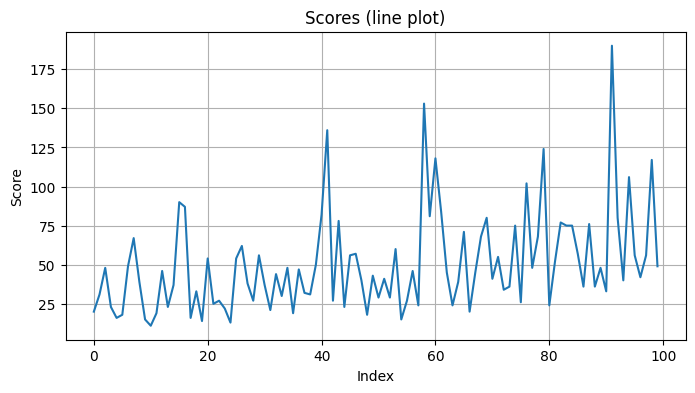

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(scores)
plt.xlabel("Index")
plt.ylabel("Score")
plt.title("Scores (line plot)")
plt.grid(True)
plt.show()

## Define evaluation method 📝
- Here we define the evaluation method that we're going to use to test our Reinforce agent.

In [19]:
def evaluate_agent(env, max_steps, n_eval_episodes, policy):
  """
  Evaluate the agent for ``n_eval_episodes`` episodes and returns average reward and std of reward.
  :param env: The evaluation environment
  :param n_eval_episodes: Number of episode to evaluate the agent
  :param policy: The Reinforce agent
  """
  episode_rewards = []
  for episode in range(n_eval_episodes):
    state, info = env.reset()
    step = 0
    done = False
    total_rewards_ep = 0

    for step in range(max_steps):
      action, _ = policy.act(state)
      new_state, reward, terminated, truncated, info = env.step(action)
      done = terminated or truncated
      total_rewards_ep += reward

      if done:
        break
      state = new_state
    episode_rewards.append(total_rewards_ep)
  mean_reward = np.mean(episode_rewards)
  std_reward = np.std(episode_rewards)

  return mean_reward, std_reward

## Evaluate our agent 📈

In [20]:
evaluate_agent(eval_env,
               cartpole_hyperparameters["max_t"],
               cartpole_hyperparameters["n_evaluation_episodes"],
               cartpole_policy)

(73.5, 38.962161131025574)

### View metrics and video for our trained model 🔥


### Create video

In [21]:
from pathlib import Path
import datetime
import json
import imageio.v2 as imageio

import tempfile

import os

In [22]:
def record_video(env, policy, out_file, fps=30):
  """
  Generate a replay video of the agent
  :param env
  :param Qtable: Qtable of our agent
  :param out_directory
  :param fps: how many frame per seconds (with taxi-v3 and frozenlake-v1 we use 1)
  """
  done = False
  state, info = env.reset()
  img = env.render()
  with imageio.get_writer(out_file, fps=fps) as writer:
      writer.append_data(np.array(img))
      while not done:
        # Take the action (index) that have the maximum expected future reward given that state
        action, _ = policy.act(state)
        state, reward, terminated, truncated, info = env.step(action) # We directly put next_state = state for recording logic
        done = terminated or truncated
        img = env.render()
        writer.append_data(np.array(img))

In [23]:
os.makedirs("video", exist_ok=True)
os.environ["SDL_AUDIODRIVER"] = "dummy"  # à mettre avant d'importer pygame / lancer l'env
video_path = "video/cartpole_v1.mp4"
record_video(eval_env, cartpole_policy, video_path)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [24]:
from IPython.display import HTML
from base64 import b64encode

mp4 = open(video_path, "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width="640" controls>
  <source src="{data_url}" type="video/mp4">
</video>
""")

Now that we try the robustness of our implementation, let's try a more complex environment: PixelCopter 🚁




## Second agent: PixelCopter 🚁

### Study the PixelCopter environment 👀
- Read [The Environment documentation](https://pygame-learning-environment.readthedocs.io/en/latest/user/games/pixelcopter.html)
  *  Do not hesitate to look at [env. code](https://pygame-learning-environment.readthedocs.io/en/latest/_modules/ple/games/pixelcopter.html#Pixelcopter.getGameState) to understand what it does.

- Note that : the state is a summary of the 2D pixel world by which the pixel copter is surrounded plus velocity data:

  * pixel copter y position.
  * pixel copter velocity.
  * pixel copter distance to floor. 
  * pixel copter distance to ceiling.
  * distance in x (forward) direction ($x_n$) between the pixel copter and the next gate block.
  * Max y of next gate-block: $y_t$ such that between $(x_n,y)$ and $(x_n,y_t)$ env is solid and in $(x_n,y_t+1)$ env is empty
  * Min y of next gate-block: $y_b$ such that between $(x_n,y_b)$ and $(x_n,y)$ env is solid and in $(x_n,y_b-1)$ env is empty


In [25]:
from gymnasium.envs.registration import register
from ple import PLE
from ple.games.pixelcopter import Pixelcopter
from gymnasium import spaces

class PixelcopterEnv(gym.Env):
    metadata = {
        "render_modes": ["human", "rgb_array", "none"],
        "render_fps": 30,
    }

    def __init__(self, render_mode=None):
        super().__init__()

        assert render_mode in (None, "human", "rgb_array", "none"), (
            f"Invalid render_mode={render_mode}. "
            "Must be one of None, 'human', 'rgb_array', 'none'."
        )
        self.render_mode = render_mode

        self.game = Pixelcopter()
        self.p = PLE(
            self.game,
            display_screen=(render_mode == "human"),
            force_fps=False,
        )
        self.p.init()

        # Build observation space from an example state
        example_state = self.p.getGameState()
        obs_dim = len(example_state)

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(obs_dim,),
            dtype=np.float32,
        )

        self.actions = self.p.getActionSet()
        self.action_space = spaces.Discrete(len(self.actions))

        # cache for last valid observation
        self._last_obs = np.zeros(self.observation_space.shape, dtype=np.float32)

    def _get_obs(self):
        """Safe wrapper around PLE.getGameState() to avoid IndexError."""
        try:
            state = self.p.getGameState()
            obs = np.array(list(state.values()), dtype=np.float32)
        except IndexError:
            # Happens when Pixelcopter has no terrain sprite for a frame
            # or right after game over. Fall back to last valid obs or zeros.
            obs = self._last_obs
        self._last_obs = obs
        return obs

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.p.reset_game()
        obs = self._get_obs()
        return obs, {}

    def step(self, action):
        # If your policy returns a tensor, make sure it's a Python int
        if not np.isscalar(action):
            action = int(action)

        reward = self.p.act(self.actions[action])
        terminated = self.p.game_over()
        truncated = False  # no time-limit truncation

        obs = self._get_obs()
        info = {}

        return obs, reward, terminated, truncated, info

    def render(self):
        if self.render_mode == "rgb_array":
            frame = self.p.getScreenRGB()
            return np.array(frame)
        elif self.render_mode == "human":
            # PLE draws to its own window when display_screen=True
            return None
        else:
            return None

    def close(self):
        self.p.quit()


env2_id = "Pixelcopter-PLE-v0"
register(
    id=env2_id,
    entry_point=PixelcopterEnv,
)

env2 = gym.make(env2_id,render_mode="rgb_array")
eval_env2 = gym.make(env2_id, render_mode="rgb_array")
s2_size = env2.observation_space.shape[0]
a2_size = env2.action_space.n

couldn't import doomish
Couldn't import doom


In [26]:
print("_____OBSERVATION SPACE_____ \n")
print("The State Space is: ", s2_size)
print("Sample observation", env2.observation_space.sample()) # Get a random observation

_____OBSERVATION SPACE_____ 

The State Space is:  7
Sample observation [-1.5803739  -0.29471183 -0.58805746  0.09975453  0.5205456  -0.65318215
 -0.12691586]


In [27]:
print("\n _____ACTION SPACE_____ \n")
print("The Action Space is: ", a2_size)
print("Action Space Sample", env2.action_space.sample()) # Take a random action


 _____ACTION SPACE_____ 

The Action Space is:  2
Action Space Sample 0


The observation space (7) 👀:
- player y position
- player velocity
- player distance to floor
- player distance to ceiling
- next block x distance to player
- next blocks top y location
- next blocks bottom y location

The action space(2) 🎮:
- Up (press accelerator)
- Do nothing (don't press accelerator)

The reward function 💰:
- For each vertical block it passes through it gains a positive reward of +1. Each time a terminal state reached it receives a negative reward of -1.

### Define the new Policy 🧠
- We need to have a deeper neural network since the environment is more complex

In [28]:
class Policy2(nn.Module):
    def __init__(self, s_size, a_size, h_size):
        super(Policy2,self).__init__()
        # Define the three layers here

    def forward(self, x):
        # Define the forward process here
        return F.softmax(x, dim=1)

    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        m = Categorical(probs)
        action = m.sample()
        return action.item(), m.log_prob(action)

#### Solution

In [29]:
class Policy2(nn.Module):
    def __init__(self, s_size, a_size, h_size):
        super(Policy2, self).__init__()
        self.s_size = s_size
        self.a_size = a_size
        self.h_size = h_size
        self.fc1 = nn.Linear(self.s_size, self.h_size)
        self.fc2 = nn.Linear(self.h_size, self.h_size*2)
        self.fc3 = nn.Linear(self.h_size*2, self.a_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return F.softmax(x, dim=1)

    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        m = Categorical(probs)
        action = m.sample()
        return action.item(), m.log_prob(action)

### Define the hyperparameters ⚙️
- Because this environment is more complex.
- Especially for the hidden size, we need more neurons.

In [35]:
pixelcopter_hyperparameters = {
    "h_size": 64,
    "n_training_episodes": 2500,#50000,
    "n_evaluation_episodes": 10,
    "max_t": 10000,
    "gamma": 0.99,
    "lr": 1e-4,
    "env_id": env2_id,
    "state_space": s2_size,
    "action_space": a2_size,
}

###  Train it
- We're now ready to train our agent 🔥.

In [36]:
# Create policy and place it to the device
# torch.manual_seed(50)
pixelcopter_policy = Policy2(pixelcopter_hyperparameters["state_space"], pixelcopter_hyperparameters["action_space"], pixelcopter_hyperparameters["h_size"]).to(device)
pixelcopter_optimizer = optim.Adam(pixelcopter_policy.parameters(), lr=pixelcopter_hyperparameters["lr"])

In [37]:
scores2 = reinforce(env2, pixelcopter_policy,
                   pixelcopter_optimizer,
                   pixelcopter_hyperparameters["n_training_episodes"],
                   pixelcopter_hyperparameters["max_t"],
                   pixelcopter_hyperparameters["gamma"],
                   250)

Episode 250	Average Score: -0.64
Episode 500	Average Score: 2.42
Episode 750	Average Score: 2.95
Episode 1000	Average Score: 5.02
Episode 1250	Average Score: 3.99
Episode 1500	Average Score: 5.42
Episode 1750	Average Score: 4.77
Episode 2000	Average Score: 4.57
Episode 2250	Average Score: 5.49
Episode 2500	Average Score: 6.56


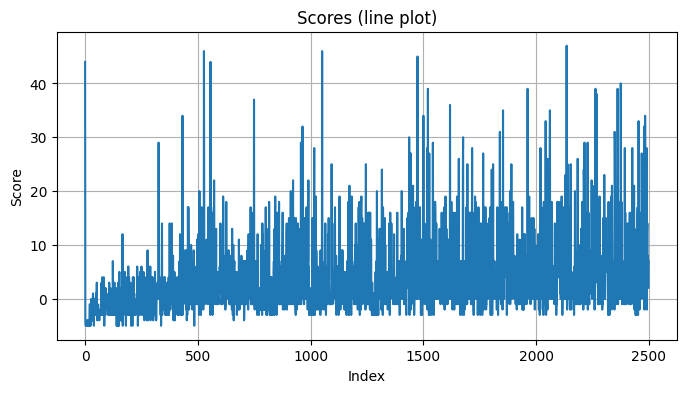

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(scores2)
plt.xlabel("Index")
plt.ylabel("Score")
plt.title("Scores (line plot)")
plt.grid(True)
plt.show()

In [41]:
video_path = "video/pixelcopter_v0.mp4"
record_video(eval_env2, pixelcopter_policy, video_path)

In [44]:
from IPython.display import HTML
from base64 import b64encode

mp4 = open(video_path, "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width="{48*6}" controls>
  <source src="{data_url}" type="video/mp4">
</video>
""")

# How to understand/evaluate RL runs, improve setup and monitor changes ?

If you have run multiple time the **reinforce** function, you have seen that the algorithm performs differently with the same parameters. 
It is due to the fact that action are sampled, that RL is a noisy learning setup and that simple gradient approaches tend to converges very slowly.

To understand what happens, you have to observe and relate your reward system with your agent performances.

A very good way to do that is to monitor your agent at key points of the training.

Furthermore, as your agent performances vary, you may want to recall at least the best score agent, and if several agents reach the best score, recall the last one (the one with the «most experience») or keep a memory of good agents.

With these 2 ideas, you can at least store videos of the agent trajectory where the agent score significantly outperform/underperform the last best agent or the last key point agent.

## The first thing is to be able to copy an agent (a policy)

In [ ]:
import copy

class MonitorLearning:
    def __init__(self):
        self.best_policy = None
        self.best_score = None
        self.turning_points = []

    def record_turning_point(self, iteration, policy, score):
        self.turning_points.append({
            "iteration": iteration,
            "score": score,
            "policy": copy.deepcopy(policy)
        })
    
    def update_best_policy(self, iteration, policy, score):
        if self.best_score is None or score > self.best_score:
            self.best_score = score
            self.best_policy = copy.deepcopy(policy)
            self.record_turning_point(iteration, policy, score)

## The second thing is to be able to detect a significant change in scores

In [ ]:
class MonitorLearning:
    def __init__(self):
        self.best_policy = None
        self.best_score = None
        self.turning_points = []
        self.score_change_percent = 10.0

    def record_turning_point(self, iteration, policy, score):
        self.turning_points.append({
            "iteration": iteration,
            "score": score,
            "policy": copy.deepcopy(policy)
        })
    
    def update_best_policy(self, iteration, policy, score):
        if self.best_score is None or score > self.best_score:
            self.best_score = score
            self.best_policy = copy.deepcopy(policy)
            self.record_turning_point(iteration, policy, score)

    def set_score_change_percent(self, percent : float):
        if percent <= 0:
            raise ValueError("Score change percent must be positive.")
        if percent > 100:
            raise ValueError("Score change percent must be less than or equal to 100.")
        self.score_change_percent = percent

    def detect_turning_point(self, iteration, policy, score, score_change_percent=None) -> bool:
        if 0 == len(self.turning_points):
            self.record_turning_point(iteration, policy, score)
            return True
        
        if score_change_percent is None:
            score_change_percent = self.score_change_percent

        last_key_score = self.turning_points[-1]["score"]
        score_change = abs(score - last_key_score)
        score_change_threshold = (score_change_percent / 100) * abs(last_key_score)
        if score_change >= score_change_threshold:
            self.record_turning_point(iteration, policy, score)
            return True
        return False
        
    def monitor( self, iteration, policy, score, score_change_percent=None):
        self.detect_turning_point(iteration, policy, score, score_change_percent)
        self.update_best_policy(iteration, policy, score)

In [ ]:
def reinforce(env, policy, optimizer, n_training_episodes, max_t, gamma, print_every, monitor):
    # Help us to calculate the score during the training
    scores_deque = deque(maxlen=100)
    scores = []
    # Line 3 of pseudocode
    for i_episode in range(1, n_training_episodes+1):
        saved_log_probs = []
        rewards = []
        state, info = env.reset()
        # Line 4 of pseudocode: generate an episode following current policy
        for t in range(max_t):
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            rewards.append(reward)
            if done:
                break
        score = sum(rewards)
        scores_deque.append(score)
        scores.append(score)
        monitor.monitor(i_episode, policy, score)

        # Line 6 of pseudocode: calculate the return
        returns = deque(maxlen=max_t)
        n_steps = len(rewards)
        # Compute the discounted returns at each timestep,
        # as
        #      the sum of the gamma-discounted return at time t (G_t) + the reward at time t
        #
        # In O(N) time, where N is the number of time steps
        # (this definition of the discounted return G_t follows the definition of this quantity
        # shown at page 44 of Sutton & Barto 2017 2nd draft)
        # G_t = r_(t+1) + r_(t+2) + ...

        # Given this formulation, the returns at each timestep t can be computed
        # by re-using the computed future returns G_(t+1) to compute the current return G_t
        # G_t = r_(t+1) + gamma*G_(t+1)
        # G_(t-1) = r_t + gamma* G_t
        # (this follows a dynamic programming approach, with which we memorize solutions in order
        # to avoid computing them multiple times)

        # This is correct since the above is equivalent to (see also page 46 of Sutton & Barto 2017 2nd draft)
        # G_(t-1) = r_t + gamma*r_(t+1) + gamma*gamma*r_(t+2) + ...


        ## Given the above, we calculate the returns at timestep t as:
        #               gamma[t] * return[t] + reward[t]
        #
        ## We compute this starting from the last timestep to the first, in order
        ## to employ the formula presented above and avoid redundant computations that would be needed
        ## if we were to do it from first to last.

        ## Hence, the queue "returns" will hold the returns in chronological order, from t=0 to t=n_steps
        ## thanks to the appendleft() function which allows to append to the position 0 in constant time O(1)
        ## a normal python list would instead require O(N) to do this.
        for t in range(n_steps)[::-1]:
            disc_return_t = (returns[0] if len(returns)>0 else 0)
            returns.appendleft( gamma*disc_return_t + rewards[t]   )

        ## standardization of the returns is employed to make training more stable
        ### NOTA BENE: extra step not in Reinforce pseudocode
        eps = np.finfo(np.float32).eps.item()

        ## eps is the smallest representable float, which will be
        # added to the standard deviation of the returns to avoid numerical instabilities
        returns = torch.tensor(returns)
        if returns.numel() > 1:
            # On some episodes, returns has length 1 (e.g. the episode terminated immediately).
            # In PyTorch, returns.std() by default uses unbiased=True (Bessel’s correction, divides by n-1).
            # If n = 1, it tries to divide by 0 → result is NaN. Now returns.std() is NaN, in that case:
            # returns = (returns - returns.mean()) / (NaN + eps)  # still NaN
            returns = (returns - returns.mean()) / (returns.std() + eps)
        else:
            returns = torch.tensor([0.], dtype=torch.float32)
            # So the advantage estimate for that episode is exactly zero.
            # That means the policy gradient update becomes:
            # loss = - log_prob(action) * 0 = 0
            # → No gradient update this episode.
            # A 1-step episode has zero variance.
            # Subtracting the mean is equivalent to subtracting the baseline.
            # If baseline = return, then the advantage is 0.
            # → the agent neither outperformed nor underperformed the baseline.
            # If the episode is extremely short, the signal isn’t useful, so skipping the update is the right thing to do.
            # If your episode ended immediately (crash / game_over), then:
            # The policy does not know whether the action was good or bad (it probably didn’t even act much).
            # A single reward sample is extremely noisy.
            # Updating based on that single sample would add noise rather than learning signal.
            # So REINFORCE avoids updating in such cases — automatically — thanks to the advantage being zero.

        # Line 7:
        policy_loss = []
        for log_prob, disc_return in zip(saved_log_probs, returns):
            policy_loss.append(-log_prob * disc_return) # Use opposite to minimize instead of maximize
        policy_loss = torch.cat(policy_loss).sum()

        # Line 8: PyTorch prefers gradient descent
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if i_episode % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(i_episode, np.mean(scores_deque)))

    return scores

## Let us put that together for cartpole deeper understanding

The idea of RL analysis is to display turning points and to compute videos associated with turnpoints in learning. This is a way to get deeper understanding of what is happening and to be able to provide quality analysis of the policy learnt. 
Then you can work to provide a solution through reward shaping, hyperparameter tuning, network architecture changes, etc.

In [ ]:
monitor_cartpole = MonitorLearning()

# 1. Run the new reinforce with cartpole 
scores_cartpole_monitored = reinforce(
    env,
    cartpole_policy,
    cartpole_optimizer,
    cartpole_hyperparameters["n_training_episodes"],
    cartpole_hyperparameters["max_t"],
    cartpole_hyperparameters["gamma"],
    100,
    monitor_cartpole
)
# Exercise: 
# 2. Plot the scores and mark the turning points as red dots
# 3. Compute videos associated with turning points
# 4. What do you observe, especially on the long run towards the side of the screen ?
# 5. Propose a new reward function to avoid this behavior
# 6. Run again the training with the new reward function

## Exercise: take the same approach for pixelcopter